# EDA 03 — Logradouros e bairros
**Projeto de extensão: Ciência de Dados para Cidades Inteligentes**

Terceiro notebook da análise exploratória. Aqui olho os dois cadastros que ajudam a localizar os chamados: os trechos de rua e os bairros.

No final, salvo as colunas desses cadastros que o `04_cruzamentos.ipynb` usa em `data/processed/`.

## 0. Preparando o ambiente
Rodo o notebook de autenticação, que instala as bibliotecas, faz os imports, define o `BILLING_PROJECT_ID` e testa a conexão com o BigQuery. Assim o ID do projeto fica escrito num lugar só.

In [4]:
%run ./00_autenticacao_bigquery.ipynb


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Ambiente pronto! Execute a próxima célula para autenticar.
Downloading: 100%|██████████|


,conexao_ok
0,1


Autenticação concluída! Projeto: etlchamadosrj


# 3. Cadastro: Logradouros
Tabela: `datario.dados_mestres.logradouro`

**Uma coisa importante que descobri:** apesar do nome, cada linha desta tabela é um **trecho** de rua (o pedaço entre dois cruzamentos), e não a rua inteira. Uma rua comprida tem vários trechos.

## 3.1 Carregando a tabela
A tabela tem duas colunas com o desenho de cada trecho no mapa (`geometry` e `geometry_wkt`). Elas são pesadas e guardam a mesma informação, então por enquanto deixo as duas de fora com `EXCEPT`.

In [5]:
consulta_logradouros = """
SELECT * EXCEPT(geometry, geometry_wkt)
FROM `datario.dados_mestres.logradouro`
"""
logradouros = bd.read_sql(consulta_logradouros, billing_project_id=BILLING_PROJECT_ID)

print("Linhas e colunas:", logradouros.shape)
display(logradouros.head())

Downloading: 100%|██████████|
Linhas e colunas: (132000, 22)


,id_trecho,id_logradouro,inicio_numero_porta_par,final_numero_porta_par,inicio_numero_porta_impar,final_numero_porta_impar,id_tipo_logradouro,tipo_logradouro_abreviado,tipo_logradouro_extenso,id_nobreza,...,nome_parcial,nome_completo,nome_mapa,id_bairro,nome_bairro,hierarquia,sentido_unico,velocidade_regulamentada,tipo_trecho,data_ultima_edicao
0,103713,81117,16.0,2.0,29.0,19.0,3,Adro,Adro,112,...,Francisco,Adro de São Francisco,Adro de São Francisco,1,Saúde,Local,N,0.0,Normal,NaT
1,99825,81117,NaN,NaN,39.0,37.0,3,Adro,Adro,112,...,Francisco,Adro de São Francisco,Adro de São Francisco,1,Saúde,Local,N,20.0,Normal,NaT
2,101117,63214,NaN,NaN,NaN,NaN,5,Av,Avenida,14,...,Tefé,Avenida Barão de Tefé,Av. Barão de Tefé,1,Saúde,Arterial secundária,FT,20.0,Normal,NaT
3,100399,63214,74.0,74.0,NaN,NaN,5,Av,Avenida,14,...,Tefé,Avenida Barão de Tefé,Av. Barão de Tefé,1,Saúde,Arterial secundária,TF,40.0,Normal,NaT
4,201879,63214,NaN,NaN,NaN,NaN,5,Av,Avenida,14,...,Tefé,Avenida Barão de Tefé,Av. Barão de Tefé,1,Saúde,Local,N,0.0,Normal,NaT


No primeiro notebook vieram **exatamente 132.000 linhas**. Um número tão redondo me deixou com a pulga atrás da orelha, então confiro a contagem direto no BigQuery:

In [6]:
display(bd.read_sql(
    "SELECT COUNT(*) AS total_linhas FROM `datario.dados_mestres.logradouro`",
    billing_project_id=BILLING_PROJECT_ID,
))

Downloading: 100%|██████████|


,total_linhas
0,132000


## 3.2 Valores faltando e valores únicos

In [7]:
resumo_logradouros = pd.DataFrame({
    "pct_nulos": (100 * logradouros.isnull().mean()).round(2),
    "valores_unicos": logradouros.nunique(),
})
display(resumo_logradouros.sort_values("pct_nulos", ascending=False))

,pct_nulos,valores_unicos
data_ultima_edicao,100.00,0
nobreza,87.22,119
inicio_numero_porta_impar,63.78,2279
final_numero_porta_impar,63.78,2302
inicio_numero_porta_par,63.28,2260
final_numero_porta_par,63.27,2272
preposicao,36.02,12
tipo_trecho,27.62,12
hierarquia,23.19,5
id_nobreza,16.96,120


**O que reparei:**
- `data_ultima_edicao` está **100% vazia**, então não serve para nada.
- A numeração das casas (`inicio_numero_porta_...`) falta em cerca de 63% dos trechos.
- `nobreza` está vazia em 87%, mas isso é normal: ela só existe em nomes com título, como "Dr." ou "Gen.".

## 3.3 Trecho ou logradouro? Entendendo o que é cada linha
Verifico três coisas:
1. Se o `id_trecho` é mesmo único (deveria ser);
2. Quantos trechos cada logradouro tem;
3. Se existem ruas que passam por mais de um bairro.

In [8]:
trechos_repetidos = logradouros[logradouros["id_trecho"].duplicated(keep=False)]
print("Linhas com id_trecho repetido:", len(trechos_repetidos))
display(trechos_repetidos.sort_values("id_trecho").head(10))

trechos_por_logradouro = logradouros.groupby("id_logradouro").size()
print("Trechos por logradouro:")
display(trechos_por_logradouro.describe())

bairros_por_logradouro = logradouros.groupby("id_logradouro")["id_bairro"].nunique()
print("Logradouros que passam por mais de um bairro:", (bairros_por_logradouro > 1).sum())

Linhas com id_trecho repetido: 13


,id_trecho,id_logradouro,inicio_numero_porta_par,final_numero_porta_par,inicio_numero_porta_impar,final_numero_porta_impar,id_tipo_logradouro,tipo_logradouro_abreviado,tipo_logradouro_extenso,id_nobreza,...,nome_parcial,nome_completo,nome_mapa,id_bairro,nome_bairro,hierarquia,sentido_unico,velocidade_regulamentada,tipo_trecho,data_ultima_edicao
71185,157642,229294,14.0,8.0,13.0,133.0,41,R,Rua,None,...,Ida Gomes,Rua Ida Gomes,R. Ida Gomes,149,Santa Cruz,None,B,30.0,None,NaT
72589,157642,320135,14.0,8.0,13.0,133.0,41,R,Rua,,...,Projetada Kambuí,Rua Projetada Kambuí,R. Projetada Kambuí,149,Santa Cruz,None,B,30.0,None,NaT
51729,180773,498915,NaN,NaN,NaN,NaN,41,R,Rua,None,...,Ebano do Novo Campinho,Rua Ebano do Novo Campinho,R. Ébano do Novo Campinho,144,Campo Grande,None,None,None,Normal,NaT
51730,180773,498915,NaN,NaN,NaN,NaN,41,R,Rua,None,...,Ebano do Novo Campinho,Rua Ebano do Novo Campinho,R. Ébano do Novo Campinho,144,Campo Grande,None,None,None,Normal,NaT
51732,180773,498915,NaN,NaN,NaN,NaN,41,R,Rua,None,...,Ebano do Novo Campinho,Rua Ebano do Novo Campinho,R. Ébano do Novo Campinho,144,Campo Grande,None,None,None,Normal,NaT
91705,203471,473686,NaN,NaN,NaN,NaN,52,Vila,Vila,,...,Flores,Vila das Flores,Vila das Flores,157,Maré,Local,N,0.0,Normal,NaT
91706,203471,473686,NaN,NaN,NaN,NaN,50,Via,Via,,...,Flores,Vila das Flores,Vila das Flores,157,Maré,Local,N,0.0,Normal,NaT
91707,203473,473686,NaN,NaN,NaN,NaN,50,Via,Via,,...,Flores,Vila das Flores,Vila das Flores,157,Maré,Local,N,0.0,Normal,NaT
91708,203473,473686,NaN,NaN,NaN,NaN,52,Vila,Vila,,...,Flores,Vila das Flores,Vila das Flores,157,Maré,Local,N,0.0,Normal,NaT
1579,55057,610295,NaN,NaN,NaN,NaN,5,Av,Avenida,None,...,Maria da Conceição Tavares,Avenida Maria da Conceição Tavares,Av. Maria da Conceição Tavares,103,Portuguesa,Local,FT,40.0,Normal,NaT


Trechos por logradouro:


count    44327.000000
mean         2.977869
std          9.201872
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max       1108.000000
dtype: float64

Logradouros que passam por mais de um bairro: 1833


**Por que isso importa?** Se eu juntar os chamados com esta tabela usando o `id_logradouro`, um chamado numa rua com 5 trechos vai aparecer **5 vezes**. A contagem de chamados ficaria errada.

A solução simples é criar uma tabela com **uma linha por logradouro** antes de juntar. Aqui fico com o primeiro trecho de cada rua. É uma simplificação: para ruas que passam por mais de um bairro, fica só um dos bairros.

In [9]:
logradouros_unicos = logradouros.drop_duplicates("id_logradouro")[["id_logradouro", "nome_completo", "id_bairro", "nome_bairro"]]
print("Logradouros únicos:", len(logradouros_unicos))
display(logradouros_unicos.head())

Logradouros únicos: 44327


,id_logradouro,nome_completo,id_bairro,nome_bairro
0,81117,Adro de São Francisco,1,Saúde
2,63214,Avenida Barão de Tefé,1,Saúde
9,62364,Avenida Rodrigues Alves,1,Saúde
14,63966,Avenida Venezuela,1,Saúde
18,70904,Beco Escadinhas da Conceição,1,Saúde


## 3.4 Tipos de logradouro e outras categorias

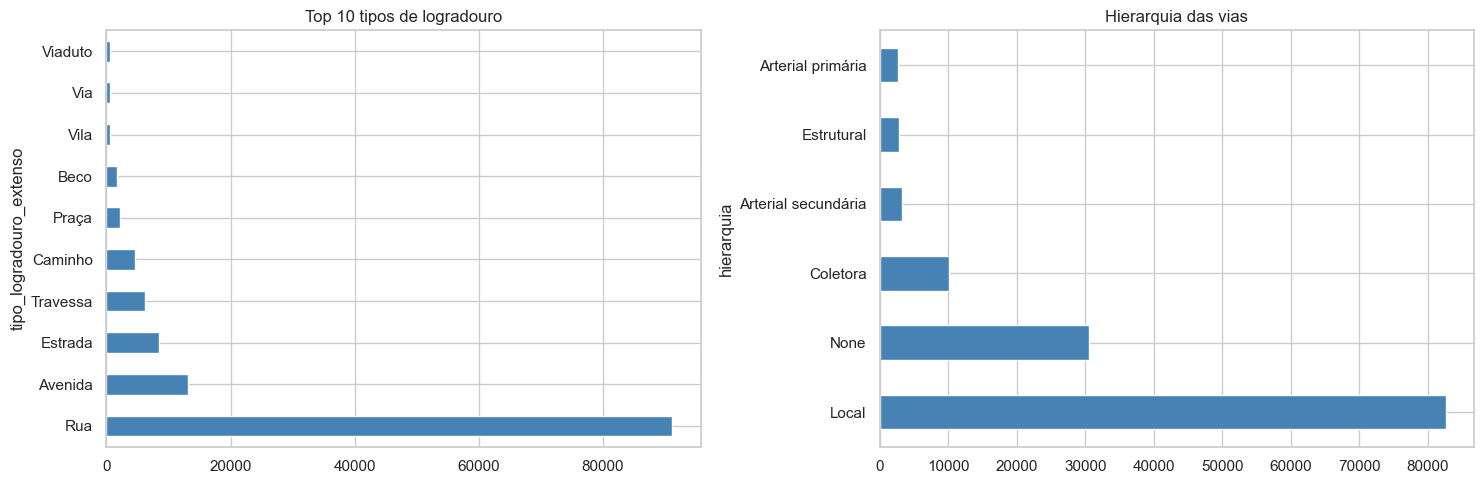

Velocidade regulamentada (km/h):


velocidade_regulamentada
0.0      20004
10.0       167
20.0     16415
30.0     75045
40.0      9385
50.0      3816
60.0      4335
70.0      1209
80.0       791
90.0       496
100.0      282
Name: count, dtype: int64

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
logradouros["tipo_logradouro_extenso"].value_counts().head(10).plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Top 10 tipos de logradouro")
logradouros["hierarquia"].value_counts(dropna=False).plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_title("Hierarquia das vias")
plt.tight_layout()
plt.show()

# A velocidade veio como texto; transformo em número
logradouros["velocidade_regulamentada"] = pd.to_numeric(logradouros["velocidade_regulamentada"], errors="coerce")
print("Velocidade regulamentada (km/h):")
display(logradouros["velocidade_regulamentada"].value_counts().sort_index())

Muitos trechos têm velocidade **0**. Provavelmente significa "não informado", e não uma rua onde não se pode andar.

## 3.5 A numeração das casas faz sentido?
O número inicial de um trecho deveria ser menor que o final. Conto os casos ao contrário. Isso pode ser só o sentido em que o trecho foi desenhado no mapa, mas é bom saber.

In [11]:
par_invertido = (logradouros["inicio_numero_porta_par"] > logradouros["final_numero_porta_par"]).sum()
impar_invertido = (logradouros["inicio_numero_porta_impar"] > logradouros["final_numero_porta_impar"]).sum()
print("Trechos com numeração par invertida:", par_invertido)
print("Trechos com numeração ímpar invertida:", impar_invertido)

Trechos com numeração par invertida: 8488
Trechos com numeração ímpar invertida: 8226


## 3.6 Quantos trechos de rua cada bairro tem?
Vou usar esse número na seção 5. Um bairro com muitas ruas tende a ter mais chamados só por ser grande.

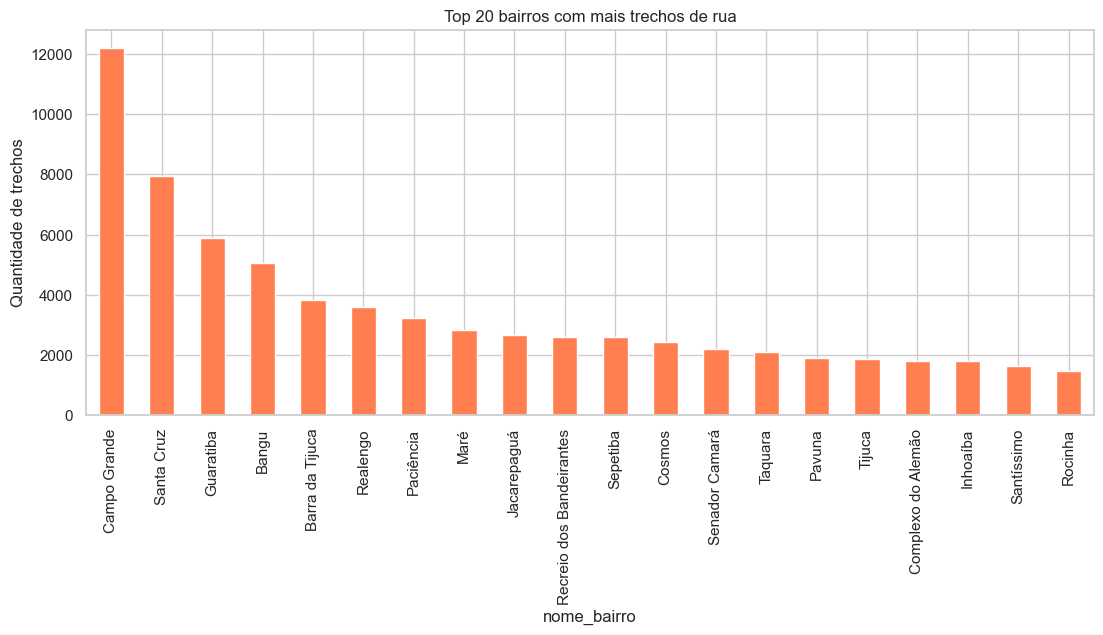

In [12]:
trechos_por_bairro = logradouros.groupby("nome_bairro").size().sort_values(ascending=False)
trechos_por_bairro.head(20).plot(kind="bar", figsize=(13, 5), color="coral")
plt.title("Top 20 bairros com mais trechos de rua")
plt.ylabel("Quantidade de trechos")
plt.show()

## 3.7 O que aprendi sobre os logradouros
- Cada linha é um **trecho**, não uma rua inteira: são cerca de 132 mil trechos para cerca de 44 mil logradouros.
- Para juntar com os chamados, preciso usar a tabela `logradouros_unicos` (uma linha por rua).
- Há alguns `id_trecho` repetidos, apesar de deverem ser únicos.
- Algumas colunas estão vazias (`data_ultima_edicao`) ou vieram com o tipo errado (`velocidade_regulamentada` como texto).

---
# 4. Cadastro de apoio: Bairros
Tabela: `datario.dados_mestres.bairro`

É uma tabela pequena, mas é ela que liga os chamados aos nomes dos bairros. Confiro se cada bairro aparece uma vez só e se os códigos batem com os da tabela de logradouros.

In [13]:
bairros = bd.read_sql(
    "SELECT id_bairro, nome FROM `datario.dados_mestres.bairro`",
    billing_project_id=BILLING_PROJECT_ID,
)
bairros["id_bairro"] = bairros["id_bairro"].astype(str)
print("Quantidade de bairros:", len(bairros))
print("Algum id_bairro repetido?", bairros["id_bairro"].duplicated().any())
display(bairros.head())

ids_na_tabela_bairros = set(bairros["id_bairro"])
ids_nos_logradouros = set(logradouros["id_bairro"].astype(str))
print("Ids que estão nos logradouros mas não na tabela de bairros:", ids_nos_logradouros - ids_na_tabela_bairros)
print("Ids que estão na tabela de bairros mas sem nenhum logradouro:", ids_na_tabela_bairros - ids_nos_logradouros)

Downloading: 100%|██████████|
Quantidade de bairros: 167
Algum id_bairro repetido? False


,id_bairro,nome
0,3,Santo Cristo
1,4,Caju
2,1,Saúde
3,2,Gamboa
4,161,Lapa


Ids que estão nos logradouros mas não na tabela de bairros: set()
Ids que estão na tabela de bairros mas sem nenhum logradouro: set()


## 4.1 Salvando os dados para os próximos notebooks
Dos logradouros, salvo só as colunas usadas nos cruzamentos (identificadores, nome da rua e bairro). Dos bairros, salvo a tabela inteira, que é pequena.

Salvo em **parquet** em vez de CSV porque esse formato guarda o tipo de cada coluna (datas continuam sendo datas) e ocupa menos espaço. A pasta `data/processed/` fica fora do Git: os arquivos são recriados sempre que o notebook roda.

In [14]:
from pathlib import Path

PASTA_PROCESSED = Path("../data/processed")
PASTA_PROCESSED.mkdir(parents=True, exist_ok=True)

colunas_cruzamentos = ["id_trecho", "id_logradouro", "nome_completo", "id_bairro", "nome_bairro"]
logradouros[colunas_cruzamentos].to_parquet(PASTA_PROCESSED / "logradouros_trechos.parquet", index=False)
bairros.to_parquet(PASTA_PROCESSED / "bairros.parquet", index=False)

print("Arquivos salvos em:", PASTA_PROCESSED.resolve())

Arquivos salvos em: C:\Users\VitorCoutoFilho\OneDrive - Urca Energia Participações Ltda\Documentos\Vitor Couto Filho\data\processed
